# Highest-Grossing Films — Data Extraction & Database Creation

This notebook scrapes data from the Wikipedia page on highest-grossing films,
cleans the data, stores it in an SQLite database, and exports it to JSON
for web visualisation.

**Data source:** https://en.wikipedia.org/wiki/List_of_highest-grossing_films

In [23]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import sqlite3
import json
import re
import time
import os

print('All libraries imported successfully')

All libraries imported successfully


## Step 1 — Fetch the Wikipedia page

A custom User-Agent header is set to avoid being blocked by Wikipedia's bot filters.

In [24]:
URL = 'https://en.wikipedia.org/wiki/List_of_highest-grossing_films'

HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/125.0.0.0 Safari/537.36'
    )
}

response = requests.get(URL, headers=HEADERS)
print(f'HTTP status: {response.status_code}')

soup = BeautifulSoup(response.text, 'html.parser')
print(f'Page title: {soup.title.string}')

HTTP status: 200
Page title: List of highest-grossing films - Wikipedia


## Step 2 — Helper functions

Two parsing helpers are defined up-front so they can be used in both
the table extraction step and the per-film scraping step.

In [25]:
# Maximum plausible worldwide box office. Used to reject concatenated values
# that appear when the scraper accidentally merges adjacent table cells.
MAX_BOX_OFFICE = 100_000_000_000


def parse_box_office(raw: str) -> float:
    """
    Extract a plausible dollar amount from a raw gross string.

    Strategy 1: find the number right after a '$' sign — most reliable.
    Strategy 2: if no '$' found, return the LARGEST number in the string
                (not the first), which avoids picking up stray digits
                from superscripts like 'F8'.
    """
    if not raw:
        return 0.0

    # Remove bracket footnotes like [1], [note 1], [# 51]
    cleaned = re.sub(r'\[.*?\]', '', raw, flags=re.DOTALL)

    # ── Strategy 1: anchor on the dollar sign ────────────────
    dollar_match = re.search(r'\$\s*([\d,]+(?:\.\d+)?)', cleaned)
    if dollar_match:
        try:
            value = float(dollar_match.group(1).replace(',', ''))
            if 0 < value <= MAX_BOX_OFFICE:
                return value
        except ValueError:
            pass

    # ── Strategy 2: take the LARGEST plausible number ────────
    stripped = re.sub(r'[^\d,.]', ' ', cleaned).strip()
    best = 0.0
    for candidate in re.findall(r'[\d,]+', stripped):
        try:
            value = float(candidate.replace(',', ''))
        except ValueError:
            continue
        if value > best and value <= MAX_BOX_OFFICE:
            best = value

    return best


def clean_text(raw: str) -> str:
    """
    Remove all Wikipedia footnote markers, nested brackets,
    and typographic symbols.
    """
    prev = None
    text = raw
    while text != prev:
        prev = text
        text = re.sub(r'\[.*?\]', '', text, flags=re.DOTALL)

    text = re.sub(r'[\[\]]', '', text)

    text = re.sub(r'[\u2020\u2021\*†‡]', '', text)

    return ' '.join(text.split())


print('Helper functions defined')

Helper functions defined


## Step 3 — Locate and parse the main table

In [26]:
tables = soup.find_all('table', class_='wikitable')

main_table = None
for table in tables:
    header_row = table.find('tr')
    if header_row:
        header_text = header_row.get_text(strip=True).lower()
        if 'worldwide gross' in header_text or 'worldwide' in header_text:
            main_table = table
            break

if main_table is None:
    for table in tables:
        if 'sortable' in table.get('class', []):
            main_table = table
            break

assert main_table is not None, 'Could not locate the main table'
print('Main table located')

header_cells = main_table.find('tr').find_all('th')
col_names = [th.get_text(strip=True).lower() for th in header_cells]
print(f'Detected columns: {col_names}')


def find_col(keywords):
    """Return the index of the first column whose header contains any of the given keywords."""
    for i, name in enumerate(col_names):
        if any(kw in name for kw in keywords):
            return i
    return None


title_idx = find_col(['title', 'film'])
gross_idx = find_col(['worldwide', 'gross'])
year_idx  = find_col(['year'])

print(f'Column mapping  ->  Title: {title_idx}, Gross: {gross_idx}, Year: {year_idx}')

Main table located
Detected columns: ['rank', 'peak', 'title', 'worldwide gross', 'year', 'ref']
Column mapping  ->  Title: 2, Gross: 3, Year: 4


In [27]:
data_rows = main_table.find_all('tr')[1:]  # skip header row

films_raw = []

for row in data_rows:
    cells = row.find_all(['td', 'th'])
    indices = list(filter(None, [title_idx, gross_idx, year_idx]))
    if not indices or len(cells) <= max(indices):
        continue

    title_cell = cells[title_idx]
    title = clean_text(title_cell.get_text(strip=True))

    link_tag = title_cell.find('a')
    film_url = None
    if link_tag and link_tag.get('href', '').startswith('/wiki/'):
        film_url = 'https://en.wikipedia.org' + link_tag['href']

    gross_raw = cells[gross_idx].get_text(strip=True) if gross_idx is not None else ''

    year_text = cells[year_idx].get_text(strip=True) if year_idx is not None else ''
    year_match = re.search(r'(19|20)\d{2}', year_text)
    year = int(year_match.group()) if year_match else None

    films_raw.append({
        'title': title,
        'box_office_raw': gross_raw,
        'release_year': year,
        'film_url': film_url,
    })

print(f'Extracted {len(films_raw)} films from the table')
print('First 5 entries:')
for f in films_raw[:5]:
    print(f"  {f['title']} ({f['release_year']}) -- {f['box_office_raw']}")

Extracted 50 films from the table
First 5 entries:
  Avatar (2009) -- $2,923,710,708
  Avengers: Endgame (2019) -- $2,797,501,328
  Avatar: The Way of Water (2022) -- $2,334,484,620
  Titanic (1997) -- T$2,257,906,828
  Ne Zha 2 (2025) -- NZ$2,215,690,000


## Step 4 — Scrape director, country, tagline, and poster from individual film pages

Each film's Wikipedia article is visited and its infobox is parsed.
A one-second delay is added between requests.

In [28]:
# Wikipedia uses several variants of the 'Directed by' label across articles
DIRECTOR_LABELS = {'directed by', 'director', 'directed'}
COUNTRY_LABELS  = {'country', 'countries', 'country of origin'}


def get_film_details(film_url: str) -> dict:
    """
    Visit a film's Wikipedia page and extract from the infobox:
      director(s), country/countries, tagline, and poster image URL.
    """
    result = {'director': 'Unknown', 'country': 'Unknown', 'tagline': '', 'poster': ''}
    if not film_url:
        return result

    try:
        resp = requests.get(film_url, headers=HEADERS, timeout=15)
        page = BeautifulSoup(resp.text, 'html.parser')
        infobox = page.find('table', class_='infobox')
        if not infobox:
            return result

        # -- Poster image --
        # Take the first infobox image that is not a tiny flag icon (width > 25px)
        for img in infobox.find_all('img'):
            src = img.get('src', '')
            try:
                width_px = int(img.get('width', '999'))
            except ValueError:
                width_px = 999
            if width_px <= 25 or 'Flag_of' in src or 'flag' in src.lower():
                continue
            # Convert thumbnail URL to full-resolution
            if '/thumb/' in src:
                # Pattern: .../thumb/a/ab/Poster.jpg/220px-Poster.jpg
                #      ->  .../en/a/ab/Poster.jpg
                after_thumb = src.split('/thumb/', 1)[1]
                base_path   = after_thumb.rsplit('/', 1)[0]  # drop 'NNpx-Poster.jpg'
                src = 'https://upload.wikimedia.org/wikipedia/en/' + base_path
            elif src.startswith('//'):
                src = 'https:' + src
            result['poster'] = src
            break

        # -- Text fields from infobox rows --
        for row in infobox.find_all('tr'):
            th = row.find('th')
            td = row.find('td')
            if not th or not td:
                continue
            label = th.get_text(separator=' ', strip=True).lower()

            if label in DIRECTOR_LABELS:
                result['director'] = clean_text(td.get_text(separator=', ', strip=True))

            elif label in COUNTRY_LABELS:
                # Split on newlines to get one country per line, then clean each
                parts = [
                    clean_text(item)
                    for item in td.get_text(separator='\n', strip=True).splitlines()
                    if item.strip() and not re.fullmatch(r'\d+', item.strip())
                ]
                # Deduplicate while preserving order
                seen = set()
                unique_parts = []
                for p in parts:
                    if p and p not in seen:
                        seen.add(p)
                        unique_parts.append(p)
                result['country'] = ', '.join(unique_parts)

            elif 'tagline' in label:
                result['tagline'] = clean_text(td.get_text(strip=True))

        # Fallback: infer United States from English-language field
        if result['country'] == 'Unknown':
            for row in infobox.find_all('tr'):
                th = row.find('th')
                td = row.find('td')
                if th and td and 'language' in th.get_text(strip=True).lower():
                    if 'english' in td.get_text(strip=True).lower():
                        result['country'] = 'United States'
                    break

    except Exception as e:
        print(f'  Warning: error fetching {film_url}: {e}')

    return result


print(f'Scraping individual pages for {len(films_raw)} films...')
print(f'Estimated time: ~{len(films_raw)} seconds\n')

for i, film in enumerate(films_raw):
    details = get_film_details(film.get('film_url'))
    film.update(details)

    if (i + 1) % 10 == 0 or i == 0:
        print(
            f"  [{i+1:>2}/{len(films_raw)}] {film['title'][:35]:<35} "
            f"poster: {'yes' if film['poster'] else 'no ':3}  "
            f"dir: {film['director'][:20]}"
        )

    time.sleep(1)

print('\nScraping complete')

Scraping individual pages for 50 films...
Estimated time: ~50 seconds

  [ 1/50] Avatar                              poster: yes  dir: James Cameron
  [10/50] Inside Out 2                        poster: yes  dir: Kelsey Mann
  [20/50] The Super Mario Bros. Movie         poster: yes  dir: Aaron Horvath, Micha
  [30/50] Iron Man 3                          poster: yes  dir: Shane Black
  [40/50] The Dark Knight Rises               poster: no   dir: Unknown
  [50/50] Pirates of the Caribbean: On Strang poster: yes  dir: Rob Marshall

Scraping complete


## Step 5 — Data cleaning

Applies `parse_box_office` (validates against $5B ceiling) and `clean_text`
to the remaining raw fields.

In [29]:
for film in films_raw:
    film['box_office'] = parse_box_office(film.pop('box_office_raw', ''))
    film['title']      = clean_text(film['title'])
    film.pop('film_url', None)

    if not film.get('release_year'):
        film['release_year'] = 0
    if not film.get('director') or film['director'] == 'Unknown':
        film['director'] = 'Unknown'
    if not film.get('country') or film['country'] == 'Unknown':
        film['country'] = 'United States'

df = pd.DataFrame(films_raw)
print(f'DataFrame shape: {df.shape}')
print(f'\nColumn dtypes:\n{df.dtypes}\n')

# Spot-check previously-problematic entries
problem_check = df[df['title'].str.contains('Furious|Avatar|Zootopia|Beauty', regex=True)]
print('Spot-check (box_office, country, director):')
print(problem_check[['title', 'box_office', 'country', 'director']].to_string(index=False))

DataFrame shape: (50, 7)

Column dtypes:
title            object
release_year      int64
director         object
country          object
tagline          object
poster           object
box_office      float64
dtype: object

Spot-check (box_office, country, director):
                   title   box_office                       country                 director
                  Avatar 2923710708.0 United States, United Kingdom            James Cameron
Avatar: The Way of Water 2334484620.0                 United States            James Cameron
              Zootopia 2 1866641191.0                 United States Jared Bush, Byron Howard
               Furious 7 1515341399.0                 United States                James Wan
    Avatar: Fire and Ash 1485829566.0                 United States            James Cameron
    Beauty and the Beast 1263521126.0                 United States              Bill Condon
 The Fate of the Furious 1238764765.0                 United States             F

## Step 6 — Create SQLite database

In [30]:
DB_PATH = os.path.join('..', 'data', 'films.db')
os.makedirs(os.path.dirname(DB_PATH), exist_ok=True)

if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

conn   = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

cursor.execute("""
    CREATE TABLE IF NOT EXISTS films (
        id           INTEGER PRIMARY KEY AUTOINCREMENT,
        title        TEXT    NOT NULL,
        release_year INTEGER,
        director     TEXT,
        box_office   REAL,
        country      TEXT,
        tagline      TEXT,
        poster       TEXT
    );
""")

INSERT_SQL = """
    INSERT INTO films (title, release_year, director, box_office, country, tagline, poster)
    VALUES (?, ?, ?, ?, ?, ?, ?);
"""

for film in films_raw:
    cursor.execute(INSERT_SQL, (
        film['title'],
        film['release_year'],
        film['director'],
        film['box_office'],
        film['country'],
        film.get('tagline', ''),
        film.get('poster', ''),
    ))

conn.commit()
count = cursor.execute('SELECT COUNT(*) FROM films').fetchone()[0]
print(f'Inserted {count} rows into films.db')

Inserted 50 rows into films.db


## Step 7 — Verify data

In [31]:
verify_df = pd.read_sql_query('SELECT * FROM films ORDER BY box_office DESC', conn)
print(f'Total films in DB: {len(verify_df)}\n')
print('Top 10 highest-grossing films:')
verify_df[['title', 'release_year', 'director', 'box_office', 'country']].head(10)

Total films in DB: 50

Top 10 highest-grossing films:


,title,release_year,director,box_office,country
0,Avatar,2009,James Cameron,2.923711e+09,"United States, United Kingdom"
1,Avengers: Endgame,2019,"Anthony Russo, Joe Russo",2.797501e+09,United States
2,Avatar: The Way of Water,2022,James Cameron,2.334485e+09,United States
3,Titanic,1997,James Cameron,2.257907e+09,United States
4,Ne Zha 2,2025,Jiaozi,2.215690e+09,China
5,Star Wars: The Force Awakens,2015,J. J. Abrams,2.068224e+09,United States
6,Avengers: Infinity War,2018,"Anthony Russo, Joe Russo",2.048360e+09,United States
7,Spider-Man: No Way Home,2021,Jon Watts,1.922599e+09,United States
8,Zootopia 2,2025,"Jared Bush, Byron Howard",1.866641e+09,United States
9,Inside Out 2,2024,Kelsey Mann,1.698864e+09,United States


In [32]:
poster_count = (verify_df['poster'] != '').sum()
print(f'Films with poster URL: {poster_count} / {len(verify_df)}')
print('\nSample poster URLs:')
for _, row in verify_df[verify_df['poster'] != ''].head(5).iterrows():
    print(f"  {row['title']}: {row['poster'][:90]}")

Films with poster URL: 46 / 50

Sample poster URLs:
  Avatar: https://upload.wikimedia.org/wikipedia/en/d/d6/Avatar_%282009_film%29_poster.jpg
  Avengers: Endgame: https://upload.wikimedia.org/wikipedia/en/0/0d/Avengers_Endgame_poster.jpg
  Avatar: The Way of Water: https://upload.wikimedia.org/wikipedia/en/5/54/Avatar_The_Way_of_Water_poster.jpg
  Titanic: https://upload.wikimedia.org/wikipedia/en/1/18/Titanic_%281997_film%29_poster.png
  Ne Zha 2: https://upload.wikimedia.org/wikipedia/en/b/b6/Ne_Zha_2_poster.jpg


## Step 8 — Data exploration

=== Box Office Statistics ===
  Mean:   $1,439,200,392
  Median: $1,299,238,083
  Max:    $2,923,710,708
  Min:    $1,045,713,802
  Year range: 1997 - 2025
  Unique directors: 36
  Unique countries: 6


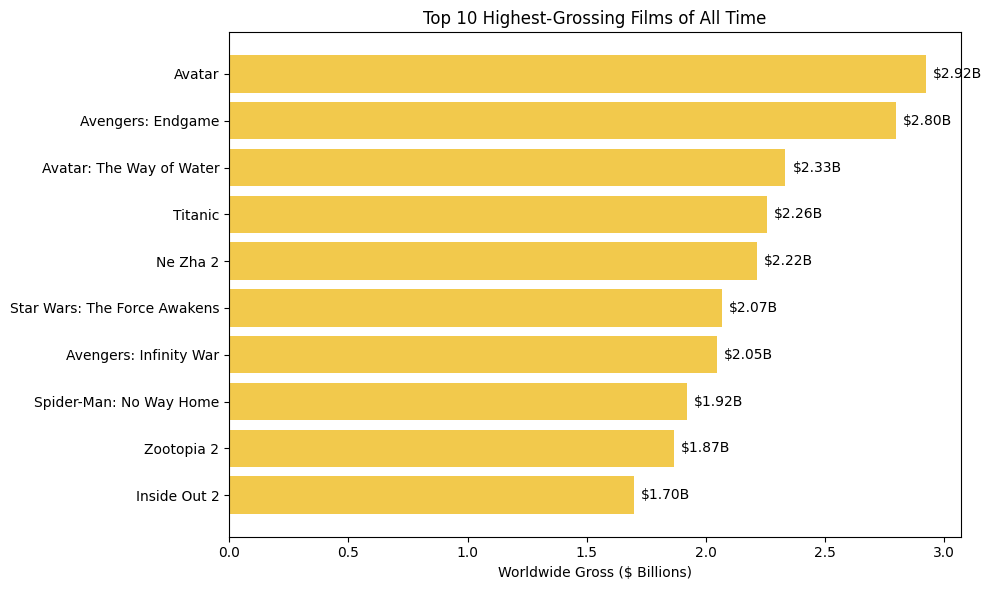

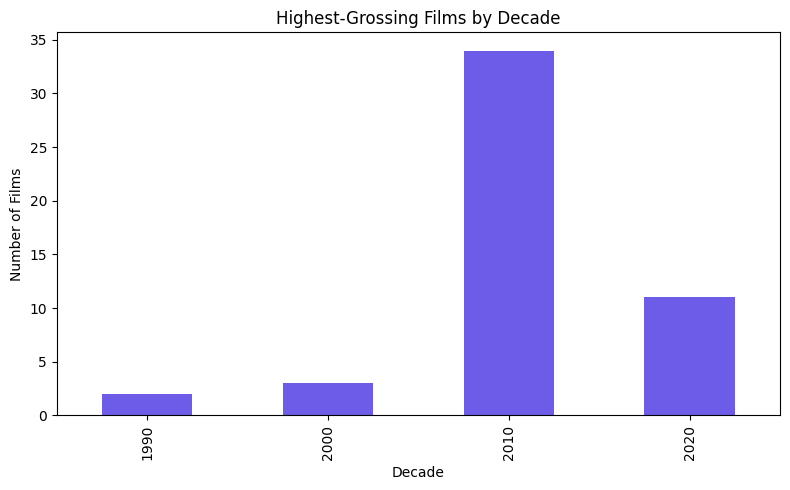

In [33]:
import matplotlib.pyplot as plt

print('=== Box Office Statistics ===')
print(f"  Mean:   ${verify_df['box_office'].mean():,.0f}")
print(f"  Median: ${verify_df['box_office'].median():,.0f}")
print(f"  Max:    ${verify_df['box_office'].max():,.0f}")
print(f"  Min:    ${verify_df['box_office'].min():,.0f}")
print(f"  Year range: {verify_df['release_year'].min()} - {verify_df['release_year'].max()}")
print(f"  Unique directors: {verify_df['director'].nunique()}")
print(f"  Unique countries: {verify_df['country'].nunique()}")

top10 = verify_df.head(10).copy()
top10['box_office_B'] = top10['box_office'] / 1e9

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['title'][::-1], top10['box_office_B'][::-1], color='#f2c94c')
ax.set_xlabel('Worldwide Gross ($ Billions)')
ax.set_title('Top 10 Highest-Grossing Films of All Time')
ax.bar_label(bars, fmt='$%.2fB', padding=5)
plt.tight_layout()
plt.show()

verify_df['decade'] = (verify_df['release_year'] // 10) * 10
decade_counts = verify_df.groupby('decade').size()

fig2, ax2 = plt.subplots(figsize=(8, 5))
decade_counts.plot(kind='bar', ax=ax2, color='#6c5ce7')
ax2.set_xlabel('Decade')
ax2.set_ylabel('Number of Films')
ax2.set_title('Highest-Grossing Films by Decade')
plt.tight_layout()
plt.show()

## Step 9 — Export to JSON

In [34]:
JSON_PATH = os.path.join('..', 'data', 'films.json')

all_films = pd.read_sql_query(
    'SELECT id, title, release_year, director, box_office, country, tagline, poster '
    'FROM films ORDER BY box_office DESC',
    conn
)
all_films = all_films.fillna('')  # replace NaN with empty string

with open(JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(all_films.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

print(f'Exported {len(all_films)} films to {JSON_PATH}')
print(f'File size: {os.path.getsize(JSON_PATH) / 1024:.1f} KB')

conn.close()
print('Database connection closed')

Exported 50 films to ..\data\films.json
File size: 14.9 KB
Database connection closed
